In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

### **DATASET OVERVIEW**

This project uses the cleaned dataset prepared during Week 1 Data Cleaning Project.

In [4]:
df=pd.read_excel("/content/cleaned_data.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [6]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


### **Convert Date Column**

In [7]:
df["Date"]=pd.to_datetime(df["Date"])

In [8]:
df["Month"]=df["Date"].dt.month_name()
df["Year"]=df["Date"].dt.year

### **3.Univariate Analysis**

**A) Product Analaysis**

In [9]:
df["Product"].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


In [10]:
product_rev=df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
product_rev

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


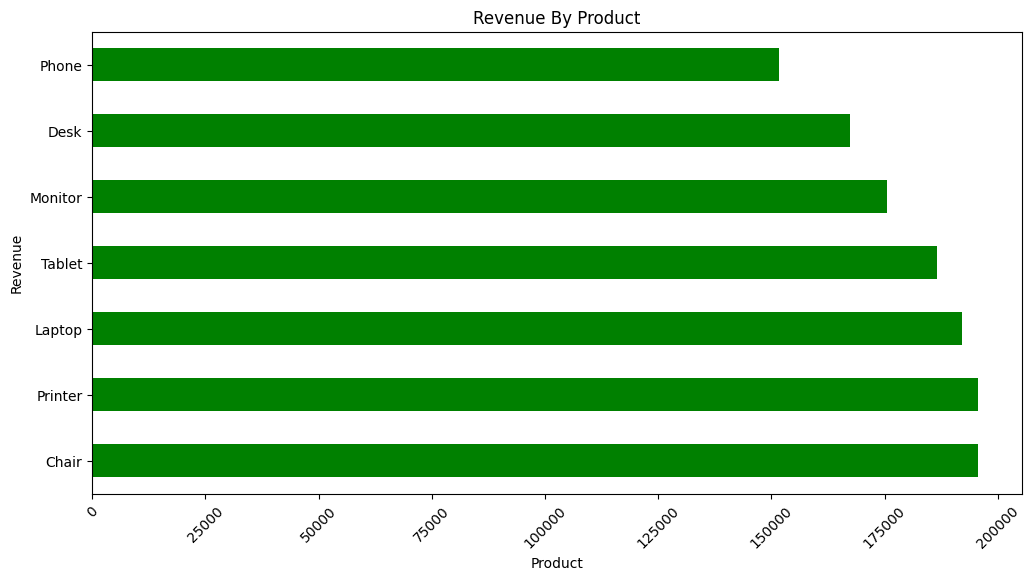

In [11]:
product_rev=df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
product_rev.plot(kind="barh",color="green")
plt.title("Revenue By Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**.** Most ordered product is Chair.

**.** Least Ordered Product is Phone.





**B)Payment method Analysis**

In [12]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


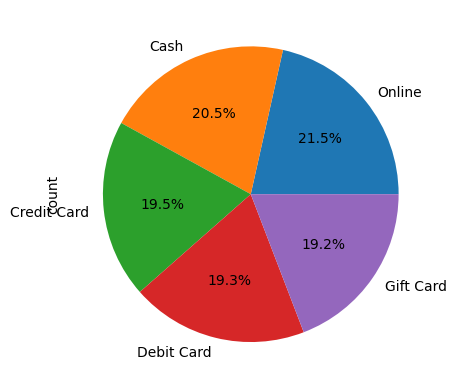

In [13]:
df["PaymentMethod"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

**.** Online is the most preferred method.

**.** The difference between  the highest (Online) and lowest (Gift Card) is only 2.3%.

**C) Order Status Analysis**

In [14]:
status_counts=df["OrderStatus"].value_counts()
status_counts

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


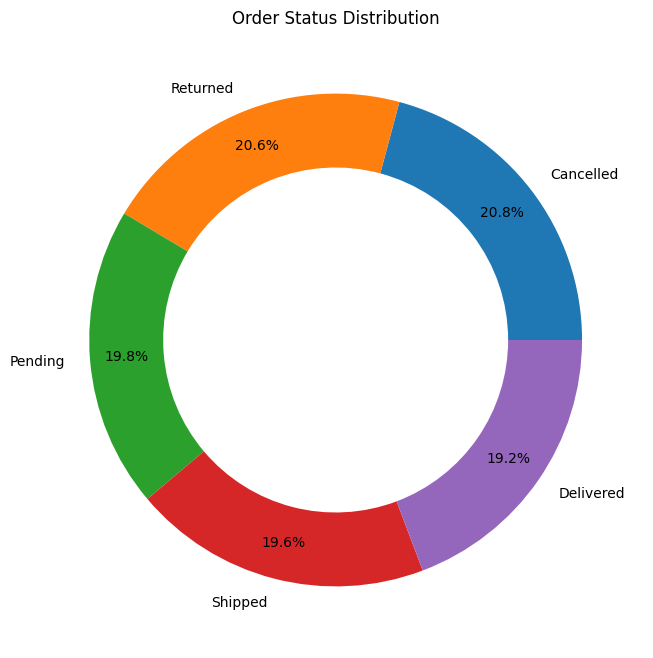

In [15]:
plt.figure(figsize=(8,8))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    pctdistance=0.85,
    wedgeprops=dict(width=0.3)
    )
plt.title("Order Status Distribution")
plt.show()

### **4. Numerical Analysis**

**Quantity Statistics**

In [16]:
df["Quantity"].describe()

,Quantity
count,1200.000000
mean,2.945833
std,1.407557
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


**Total Price Statistics**

In [17]:
df["TotalPrice"].describe()

,TotalPrice
count,1200.000000
mean,1053.968300
std,819.856558
min,11.390000
25%,410.520000
50%,823.615000
75%,1578.475000
max,3456.400000


**Bivariate Analysis**

**Cart Size vs Order Value **

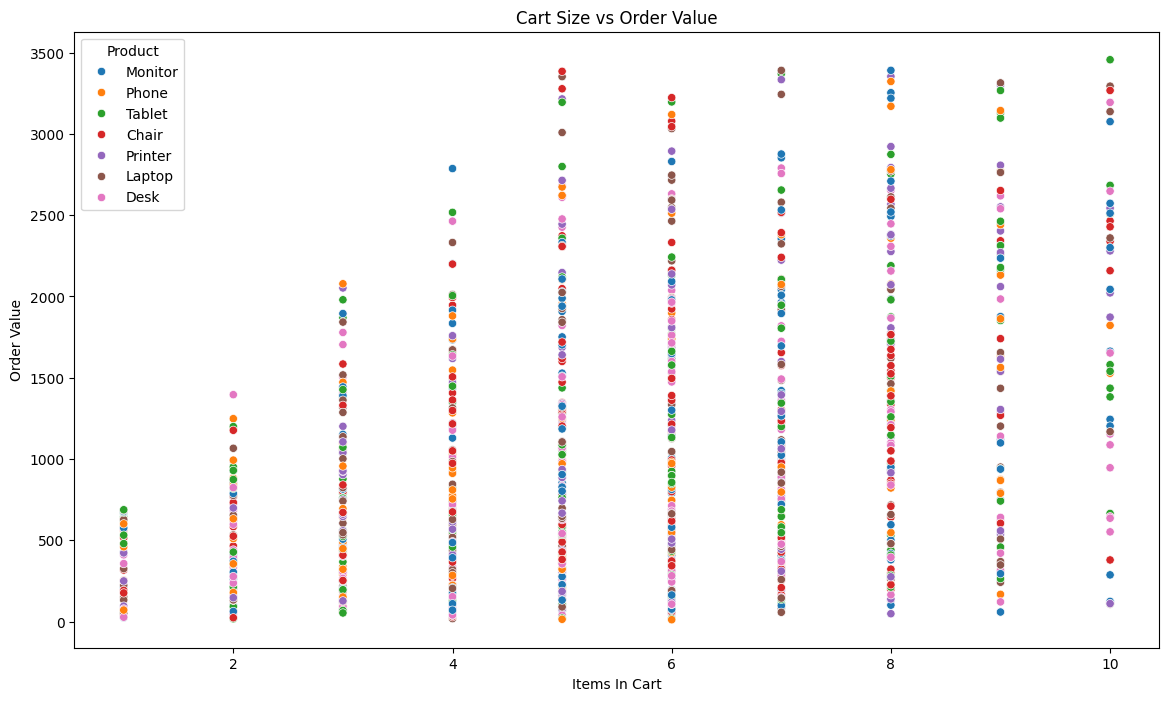

In [18]:
plt.figure(figsize=(14,8))
sns.scatterplot(data=df,x="ItemsInCart",y="TotalPrice",hue="Product")
plt.title("Cart Size vs Order Value")
plt.xlabel("Items In Cart")
plt.ylabel("Order Value")
plt.show()

**Orders and Revenue By Referral Source**

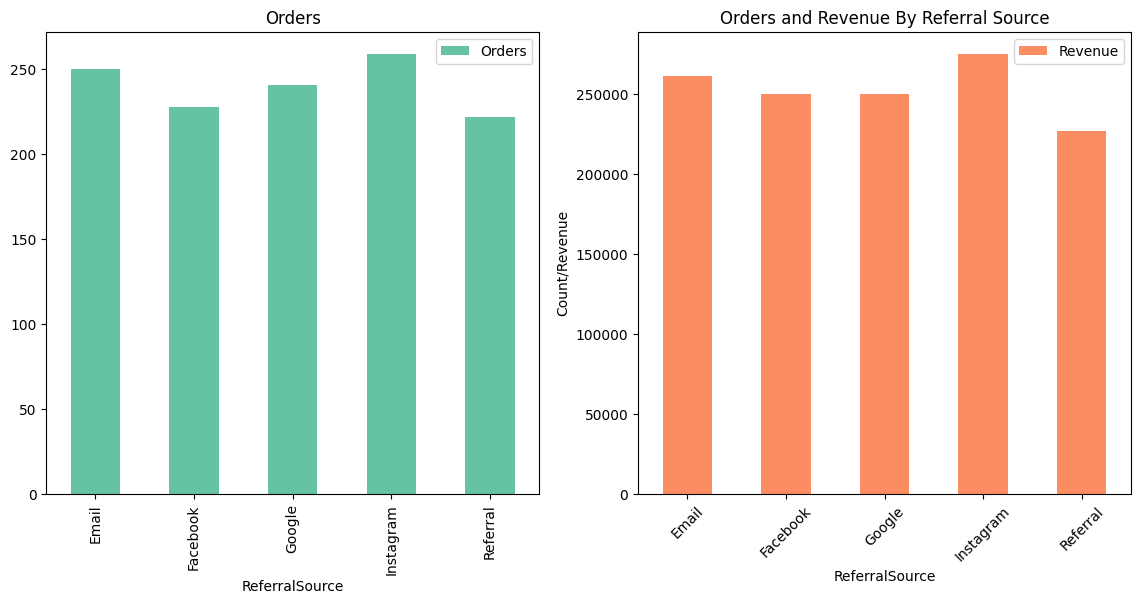

In [19]:
referral=df.groupby("ReferralSource").agg(
    Orders=("OrderID","count"),
    Revenue=("TotalPrice","sum")
)
referral.plot(kind="bar",subplots=True,layout=(1,2),figsize=(14,6),color=["#66c2a5","#fc8d62"])
plt.title("Orders and Revenue By Referral Source")
plt.ylabel("Count/Revenue")
plt.xticks(rotation=45)
plt.show()

### **Multivariate Analysis**

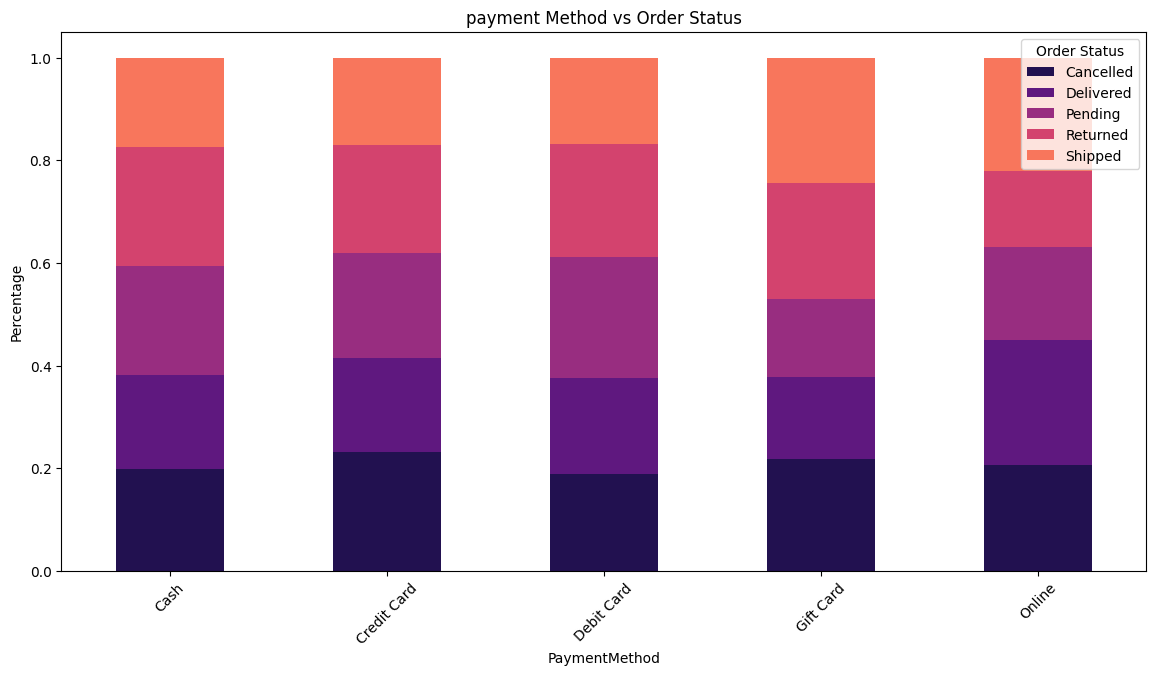

In [20]:
cross=pd.crosstab(df["PaymentMethod"],df["OrderStatus"],normalize="index")
cross.plot(kind="bar",stacked=True,figsize=(14,7),color=sns.color_palette("magma"))
plt.title("payment Method vs Order Status")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Order Status")
plt.show()

**Revenue Heatmap**

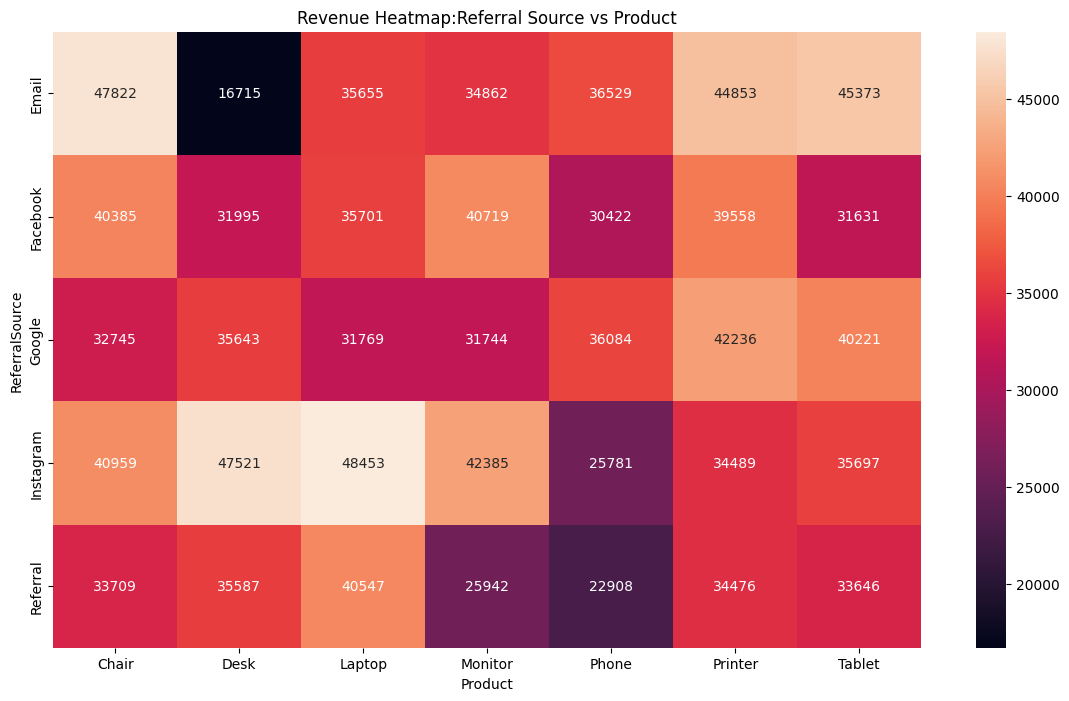

In [21]:
mapping=pd.pivot_table(df,values="TotalPrice",index="ReferralSource",columns="Product",aggfunc="sum")
plt.figure(figsize=(14,8))
sns.heatmap(mapping,annot=True,fmt=".0f")
plt.title("Revenue Heatmap:Referral Source vs Product")
plt.show()

### **5. Trend Analysis**

**Monthly Revenue Line Chart**

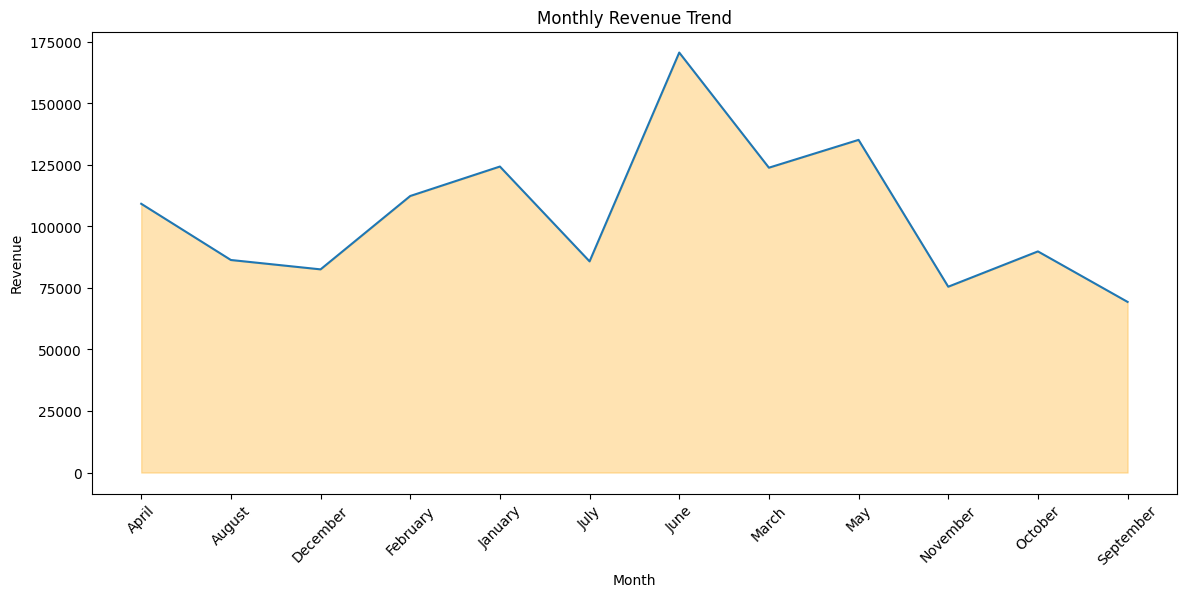

In [22]:
monthly_rev=df.groupby("Month")["TotalPrice"].sum()
plt.figure(figsize=(14,6))
plt.plot(monthly_rev.index.astype(str),monthly_rev.values)
plt.fill_between(monthly_rev.index.astype(str),monthly_rev.values,alpha=0.3,color='orange')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Outlier Detection

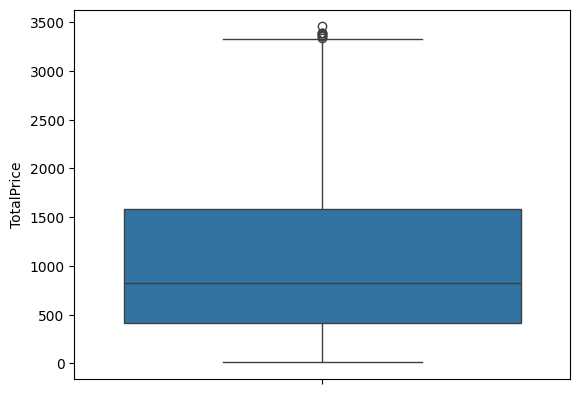

In [23]:
sns.boxplot(df["TotalPrice"])
plt.show()